# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech
- Nama: Devian Wahyu Nugroho
- Email: devianwahyu@dicoding.com
- Id Dicoding: devianwahyu

## Persiapan
### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os

### Menyiapkan data yang akan digunakan

In [2]:
# Membaca dataset
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                       

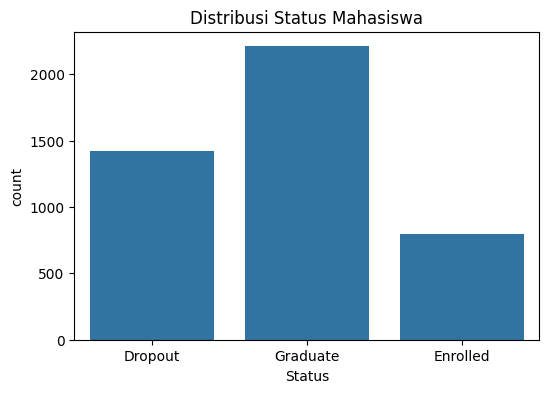

In [3]:
print("Informasi Dataset:")
df.info()

print("\nDistribusi Target (Status):")
print(df['Status'].value_counts())

# Visualisasi Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Status')
plt.title('Distribusi Status Mahasiswa')
plt.show()

## Data Preparation / Preprocessing

In [4]:
# Membuat target biner (Dropout vs Non-Dropout)
df['Dropout_Flag'] = df['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

# Memisahkan fitur dan target
X = df.drop(columns=['Status', 'Dropout_Flag'])
y = df['Dropout_Flag']

# Membagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Ukuran X_train: (3539, 36)
Ukuran X_test: (885, 36)


## Modeling

In [5]:
# Melatih model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Evaluation

Accuracy: 0.8790960451977401

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       601
           1       0.88      0.72      0.79       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.85       885
weighted avg       0.88      0.88      0.88       885



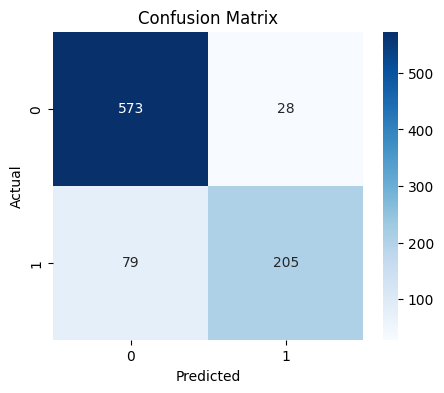

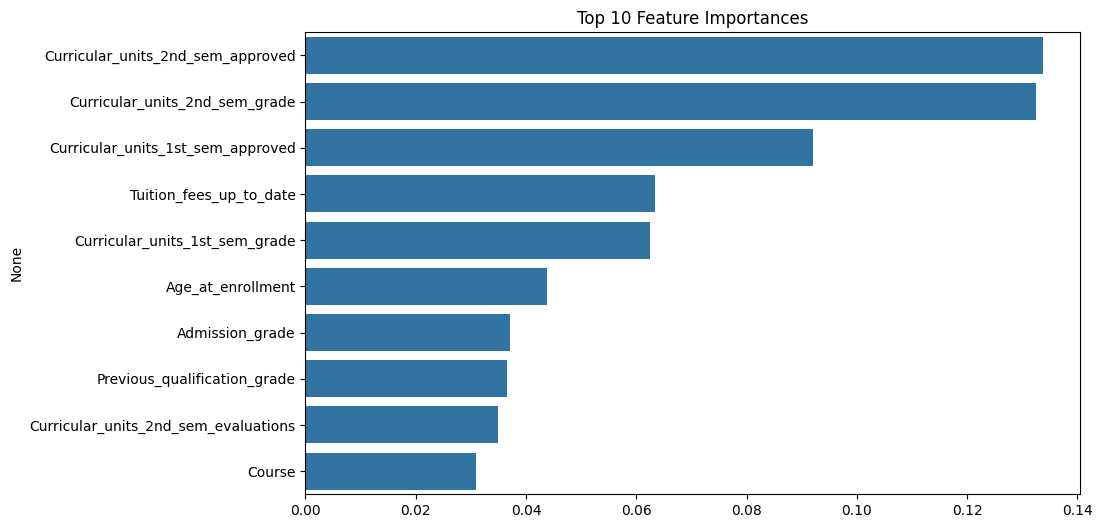

Model berhasil disimpan di model/model.joblib


In [6]:
# Prediksi pada testing set
y_pred = rf_model.predict(X_test)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:10], y=features[indices][:10])
plt.title('Top 10 Feature Importances')
plt.show()

# Simpan Model
if not os.path.exists('model'):
    os.makedirs('model')
joblib.dump(rf_model, 'model/model.joblib')
print("Model berhasil disimpan di model/model.joblib")
